# Machine Learning Credit Risk Model
## Part 4: Hyperparameter Tuning, Model Combination, and Final Evaluation


**Dataset:** LendingClub Loan Data (`accepted_2007_to_2018Q4.csv.gz`)  
**Objective:** Systematically tune hyperparameters for the three supervised models developed in Part 3 (Logistic Regression, Random Forest, XGBoost), combine the best models into a soft-voting ensemble, evaluate all tuned models on the held-out test set, and produce documented recommendations.

---

## Table of Contents
1. Project Overview
2. Import Libraries
3. Data Preparation (Self-Contained)
4. Baseline Model Recreation
5. Hyperparameter Tuning — Logistic Regression
6. Hyperparameter Tuning — Random Forest
7. Hyperparameter Tuning — XGBoost
8. Classification Threshold Optimization
9. Model Combination — Soft Voting Ensemble
10. Final Evaluation on Held-Out Test Set
11. Results Summary and Analysis
12. Recommendations
13. Suggestions for Further Work

---
## 1. Project Overview

### Business Context
This notebook is the hyperparameter tuning and final evaluation stage of a credit risk modeling pipeline applied to the LendingClub peer-to-peer lending dataset. The target variable is binary loan default (1 = Charged Off, 0 = Fully Paid). Accurate default predictions allow lenders to improve underwriting decisions, set appropriate interest rates, and reduce expected credit losses.

In Part 3, three supervised models were trained using manually selected hyperparameters chosen based on domain knowledge and general best practices:

| Model | Key Part 3 Hyperparameters | Part 3 AUC (expected) |
|---|---|---|
| Logistic Regression | C=1.0, penalty=l2, solver=lbfgs | ~0.70 |
| Random Forest | n_estimators=200, max_depth=12 | ~0.73 |
| XGBoost | n_estimators=300, max_depth=5, lr=0.05 | ~0.74 |

This notebook applies structured, data-driven hyperparameter search to find configurations that maximize AUC-ROC on a cross-validated training set, then reports final unbiased performance on the held-out test set that was locked away in Part 3.

### Hyperparameter Tuning Strategy
**RandomizedSearchCV** is used rather than exhaustive GridSearchCV for the following reasons:
- The combined hyperparameter space for Random Forest and XGBoost is extremely large (millions of combinations for full grid search)
- Random search over a continuous or large discrete space has been shown to find near-optimal configurations far more efficiently than grid search (Bergstra & Bengio, 2012)
- 5-fold stratified cross-validation on the training set provides a reliable AUC estimate without touching the test set
- Each random search run explores a fixed budget of candidate configurations (n_iter), making compute time predictable

### Evaluation Metric
**AUC-ROC** is the primary metric for all tuning and comparison because:
- It measures discrimination ability across all probability thresholds simultaneously
- It is insensitive to class imbalance (~80% Fully Paid / ~20% Charged Off)
- A lender can then choose the operating threshold that matches their specific risk appetite after model selection

Secondary metrics reported: Accuracy, Precision, Recall, F1 (at the optimized threshold).

### Reproducibility
All random seeds are set to 42. The 80/20 train/test split uses `stratify=y` and `random_state=42`, identical to Part 3, so the exact same held-out test observations are used for final evaluation.

---
## 2. Import Libraries

In [ ]:
# ============================================================
# IMPORT LIBRARIES
# ============================================================
# Install any missing package from a terminal:
#   pip install pandas numpy matplotlib seaborn scikit-learn xgboost
# ============================================================

# --- Core data manipulation ---
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# --- Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')
pd.set_option('display.max_columns', None)

# --- Preprocessing & splitting ---
from sklearn.model_selection import (
    train_test_split,
    RandomizedSearchCV,
    StratifiedKFold,
    cross_val_score
)
from sklearn.preprocessing import StandardScaler

# --- Evaluation metrics ---
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    confusion_matrix,
    classification_report
)

# --- Supervised models ---
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

# --- XGBoost ---
try:
    import xgboost as xgb
    print('XGBoost version:', xgb.__version__)
except ImportError:
    raise ImportError('XGBoost not found. Run: pip install xgboost')

# --- SciPy distributions for random search ---
from scipy.stats import loguniform, randint, uniform

# --- Reproducibility ---
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('All libraries loaded successfully.')

XGBoost version: 3.2.0
All libraries loaded successfully.


---
## 3. Data Preparation (Self-Contained)

This section replicates the complete data preparation pipeline from Part 3 in a single, self-contained block. This notebook can be executed independently without running any prior notebook. Every transformation is applied in the same order with the same parameters, ensuring identical feature engineering and the exact same train/test split.

**Pipeline steps:**
1. Load 200,000 rows of the compressed LendingClub dataset
2. Select nine relevant variables and filter to final outcomes
3. Create binary default target (1 = Charged Off, 0 = Fully Paid)
4. Clean `int_rate` and `term` formats
5. Impute missing values (median for numerics, 'Unknown' for categoricals)
6. Engineer `loan_to_income` and `high_dti_flag`
7. Apply log transformations to `loan_amnt` and `annual_inc`
8. Encode `emp_length` to ordinal numeric and one-hot encode `home_ownership`
9. Define 13-feature modeling set
10. Stratified 80/20 train/test split (random_state=42)
11. StandardScaler fit on training data only, applied to both splits

In [ ]:
# ============================================================
# STEP 3.1 — LOAD DATASET
# ============================================================
# LendingClub data is stored in the same directory as this
# notebook. 200,000 rows are loaded — sufficient to capture
# meaningful patterns while keeping memory usage manageable.
# ============================================================

# Data file is located in the Part 2 directory.
# Update this path if running from a different location.
FILE_PATH = 'accepted_2007_to_2018Q4.csv.gz'

df = pd.read_csv(
    FILE_PATH,
    compression='gzip',
    nrows=200000,
    low_memory=False
)

print('Dataset loaded. Raw shape:', df.shape)

Dataset loaded. Raw shape: (200000, 151)


In [ ]:
# ============================================================
# STEP 3.2 — SELECT VARIABLES AND DEFINE TARGET
# ============================================================

selected_cols = [
    'loan_amnt', 'int_rate', 'annual_inc', 'dti',
    'fico_range_high', 'term', 'emp_length',
    'home_ownership', 'loan_status'
]

df = df[selected_cols]
df = df[df['loan_status'].isin(['Fully Paid', 'Charged Off'])].copy()
df['default'] = np.where(df['loan_status'] == 'Charged Off', 1, 0)

print('Shape after filtering to final outcomes:', df.shape)
print('Default rate: {:.1f}%'.format(df['default'].mean() * 100))

Shape after filtering to final outcomes: (176082, 10)
Default rate: 19.9%


In [ ]:
# ============================================================
# STEP 3.3 — CLEAN VARIABLE FORMATS
# ============================================================

# int_rate: handle both string ('13.5%') and numeric formats
if df['int_rate'].dtype == object:
    df['int_rate'] = df['int_rate'].str.replace('%', '', regex=False)
df['int_rate'] = pd.to_numeric(df['int_rate'], errors='coerce')

# term: extract leading number from '36 months' or '60 months'
df['term'] = df['term'].astype(str).str.extract(r'(\d+)').astype(float)

print('int_rate dtype:', df['int_rate'].dtype)
print('term unique values:', sorted(df['term'].dropna().unique()))

int_rate dtype: float64
term unique values: [np.float64(36.0), np.float64(60.0)]


In [ ]:
# ============================================================
# STEP 3.4 — IMPUTE MISSING VALUES
# ============================================================

NUMERIC_COLS = ['loan_amnt', 'int_rate', 'annual_inc', 'dti', 'fico_range_high', 'term']

for col in NUMERIC_COLS:
    median_val = df[col].median()
    missing    = df[col].isna().sum()
    if missing > 0:
        df[col] = df[col].fillna(median_val)
        print(f'{col}: filled {missing} missing values with median={median_val:.2f}')

df['emp_length']    = df['emp_length'].fillna('Unknown')
df['home_ownership'] = df['home_ownership'].fillna('Unknown')

print()
print('Missing values after imputation:')
print(df.isnull().sum()[df.isnull().sum() > 0])

dti: filled 2 missing values with median=18.34

Missing values after imputation:
Series([], dtype: int64)


In [ ]:
# ============================================================
# STEP 3.5 — FEATURE ENGINEERING
# ============================================================

# loan_to_income: leverage ratio capturing affordability
df['loan_to_income'] = df['loan_amnt'] / (df['annual_inc'] + 1)

# high_dti_flag: binary flag for elevated debt burden (DTI > 30%)
df['high_dti_flag'] = (df['dti'] > 30).astype(int)

# Log transforms to reduce right-skew in large numeric fields
df['log_loan_amnt'] = np.log1p(df['loan_amnt'])
df['log_annual_inc'] = np.log1p(df['annual_inc'])

print('Engineered features added: loan_to_income, high_dti_flag, log_loan_amnt, log_annual_inc')

Engineered features added: loan_to_income, high_dti_flag, log_loan_amnt, log_annual_inc


In [ ]:
# ============================================================
# STEP 3.6 — ENCODE CATEGORICAL VARIABLES
# ============================================================

# emp_length: ordinal encoding (Unknown → 0, < 1 year → 1, ..., 10+ years → 11)
emp_length_map = {
    'Unknown': 0, '< 1 year': 1, '1 year': 2, '2 years': 3,
    '3 years': 4, '4 years': 5, '5 years': 6, '6 years': 7,
    '7 years': 8, '8 years': 9, '9 years': 10, '10+ years': 11
}
df['emp_length_num'] = df['emp_length'].map(emp_length_map).fillna(0).astype(int)

# home_ownership: one-hot encode MORTGAGE, OWN, RENT
home_dummies = pd.get_dummies(df['home_ownership'], prefix='home')
for col in ['home_MORTGAGE', 'home_OWN', 'home_RENT']:
    if col not in home_dummies.columns:
        home_dummies[col] = 0
df = pd.concat([df, home_dummies[['home_MORTGAGE', 'home_OWN', 'home_RENT']]], axis=1)

print('Encoding complete.')
print('emp_length_num range:', df['emp_length_num'].min(), 'to', df['emp_length_num'].max())

Encoding complete.
emp_length_num range: 0 to 11


In [ ]:
# ============================================================
# STEP 3.7 — DEFINE FEATURE SET AND TARGET
# ============================================================
# 13 features — identical to Part 3
# ============================================================

FEATURE_COLS = [
    'loan_amnt',      # Loan amount requested
    'int_rate',       # Interest rate (risk-based price)
    'dti',            # Debt-to-income ratio
    'fico_range_high', # FICO credit score (high range)
    'term',           # Loan term (36 or 60 months)
    'loan_to_income', # Leverage ratio
    'high_dti_flag',  # Binary: DTI > 30
    'log_loan_amnt',  # Log-transformed loan amount
    'log_annual_inc', # Log-transformed annual income
    'emp_length_num', # Employment length (ordinal)
    'home_MORTGAGE',  # Binary: has mortgage
    'home_OWN',       # Binary: owns home outright
    'home_RENT'       # Binary: rents
]

TARGET_COL = 'default'

X = df[FEATURE_COLS].copy()
y = df[TARGET_COL].copy()

print('Feature matrix shape:', X.shape)
print('Target distribution:')
print(y.value_counts())

Feature matrix shape: (176082, 13)
Target distribution:
default
0    140992
1     35090
Name: count, dtype: int64


In [ ]:
# ============================================================
# STEP 3.8 — TRAIN / TEST SPLIT
# ============================================================
# 80/20 stratified split with random_state=42 — IDENTICAL to
# Part 3. The test set is held out and used only in Section 10.
# All tuning (Sections 5-7) operates exclusively on X_train.
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print('Training set:', X_train.shape, '| Default rate: {:.1f}%'.format(y_train.mean() * 100))
print('Test set    :', X_test.shape,  '| Default rate: {:.1f}%'.format(y_test.mean() * 100))

Training set: (140865, 13) | Default rate: 19.9%
Test set    : (35217, 13) | Default rate: 19.9%


In [ ]:
# ============================================================
# STEP 3.9 — FEATURE SCALING (StandardScaler)
# ============================================================
# Fit the scaler on training data only. Apply (without re-fitting)
# to the test set. This prevents data leakage from the test set
# into the scaling statistics.
# ============================================================

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Compute class imbalance ratio for XGBoost
n_neg = (y_train == 0).sum()
n_pos = (y_train == 1).sum()
SCALE_POS_WEIGHT = n_neg / n_pos

print('Scaling complete.')
print(f'Negative class (Fully Paid): {n_neg:,}')
print(f'Positive class (Charged Off): {n_pos:,}')
print(f'scale_pos_weight (for XGBoost): {SCALE_POS_WEIGHT:.3f}')

Scaling complete.
Negative class (Fully Paid): 112,793
Positive class (Charged Off): 28,072
scale_pos_weight (for XGBoost): 4.018


---
## 4. Baseline Model Recreation

Before tuning, the three Part 3 models are re-trained using their original hyperparameters. This establishes a clean, comparable baseline on the same data pipeline. All tuned models will be measured against these baselines to quantify the improvement from systematic tuning.

A shared evaluation function is defined here and reused throughout the notebook.

In [ ]:
# ============================================================
# SHARED EVALUATION FUNCTION
# ============================================================
# evaluate_model(): computes and prints a full metric report
# for any binary classifier given true labels and predicted
# probabilities. Returns a results dict for table assembly.
#
# threshold: the decision boundary for converting probability
#   to class label. Default=0.5. An optimized threshold is
#   computed in Section 8 and reused in Section 10.
# ============================================================

def evaluate_model(name, y_true, y_prob, threshold=0.5, print_report=True):
    """Evaluate a binary classifier. Returns a results dictionary."""
    y_pred = (y_prob >= threshold).astype(int)
    auc    = roc_auc_score(y_true, y_prob)
    acc    = accuracy_score(y_true, y_pred)
    prec   = precision_score(y_true, y_pred, zero_division=0)
    rec    = recall_score(y_true, y_pred, zero_division=0)
    f1     = f1_score(y_true, y_pred, zero_division=0)

    if print_report:
        print(f'Model: {name}  |  Threshold: {threshold:.2f}')
        print(f'  AUC-ROC   : {auc:.4f}')
        print(f'  Accuracy  : {acc:.4f}')
        print(f'  Precision : {prec:.4f}')
        print(f'  Recall    : {rec:.4f}')
        print(f'  F1        : {f1:.4f}')
        print()
        cm = confusion_matrix(y_true, y_pred)
        print('Confusion Matrix:')
        print(f'  TN={cm[0,0]:,}  FP={cm[0,1]:,}')
        print(f'  FN={cm[1,0]:,}  TP={cm[1,1]:,}')
        print()

    return {
        'Model': name, 'Threshold': threshold,
        'AUC': auc, 'Accuracy': acc,
        'Precision': prec, 'Recall': rec, 'F1': f1
    }

print('evaluate_model() defined.')

evaluate_model() defined.


In [ ]:
# ============================================================
# BASELINE MODEL 1 — LOGISTIC REGRESSION (Part 3 parameters)
# ============================================================

print('Training Logistic Regression baseline...')

lr_baseline = LogisticRegression(
    C=1.0,
    penalty='l2',
    solver='lbfgs',
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE
)
lr_baseline.fit(X_train_scaled, y_train)

lr_base_prob = lr_baseline.predict_proba(X_test_scaled)[:, 1]
lr_base_auc  = roc_auc_score(y_test, lr_base_prob)
print(f'Logistic Regression Baseline — Test AUC: {lr_base_auc:.4f}')

Training Logistic Regression baseline...
Logistic Regression Baseline — Test AUC: 0.7397


In [ ]:
# ============================================================
# BASELINE MODEL 2 — RANDOM FOREST (Part 3 parameters)
# ============================================================

print('Training Random Forest baseline (1-2 minutes)...')

rf_baseline = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1,
    random_state=RANDOM_STATE
)
rf_baseline.fit(X_train_scaled, y_train)

rf_base_prob = rf_baseline.predict_proba(X_test_scaled)[:, 1]
rf_base_auc  = roc_auc_score(y_test, rf_base_prob)
print(f'Random Forest Baseline — Test AUC: {rf_base_auc:.4f}')

Training Random Forest baseline (1-2 minutes)...
Random Forest Baseline — Test AUC: 0.7399


In [ ]:
# ============================================================
# BASELINE MODEL 3 — XGBOOST (Part 3 parameters)
# ============================================================

print('Training XGBoost baseline (2-3 minutes)...')

xgb_baseline = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=SCALE_POS_WEIGHT,
    eval_metric='auc',
    random_state=RANDOM_STATE,
    verbosity=0
)
xgb_baseline.fit(X_train_scaled, y_train)

xgb_base_prob = xgb_baseline.predict_proba(X_test_scaled)[:, 1]
xgb_base_auc  = roc_auc_score(y_test, xgb_base_prob)
print(f'XGBoost Baseline — Test AUC: {xgb_base_auc:.4f}')

Training XGBoost baseline (2-3 minutes)...
XGBoost Baseline — Test AUC: 0.7423


In [ ]:
# ============================================================
# BASELINE SUMMARY
# ============================================================

print('=' * 50)
print('BASELINE PERFORMANCE (Part 3 hyperparameters)')
print('=' * 50)
print(f'{"Model":<25} {"Test AUC":<12}')
print('-' * 38)
print(f'{"Logistic Regression":<25} {lr_base_auc:.4f}')
print(f'{"Random Forest":<25} {rf_base_auc:.4f}')
print(f'{"XGBoost":<25} {xgb_base_auc:.4f}')
print()
print('These baseline AUC values are the benchmarks against which')
print('all tuned models will be compared in Section 10.')

BASELINE PERFORMANCE (Part 3 hyperparameters)
Model                     Test AUC    
--------------------------------------
Logistic Regression       0.7397
Random Forest             0.7399
XGBoost                   0.7423

These baseline AUC values are the benchmarks against which
all tuned models will be compared in Section 10.


---
## 5. Hyperparameter Tuning — Logistic Regression

### Why Tune Logistic Regression?
Logistic Regression has fewer hyperparameters than tree-based models, but the regularization strength `C` is highly consequential: too large allows the model to overfit noisy features, while too small shrinks coefficients toward zero and underfits. The `penalty` type also matters — L1 (Lasso) performs feature selection by zeroing coefficients, while L2 (Ridge) retains all features with small weights. For a credit risk context where interpretability is valued, understanding which penalty produces a better-calibrated model is important.

### Search Space Design
| Hyperparameter | Search Distribution | Rationale |
|---|---|---|
| `C` | loguniform(1e-4, 100) | Regularization spans orders of magnitude; log scale appropriate |
| `penalty` | ['l1', 'l2'] | L1 induces sparsity; L2 retains all features with dampened weights |
| `solver` | ['liblinear', 'saga'] | These solvers support both L1 and L2 penalties |
| `max_iter` | [1000] | Fixed; convergence is not a tuning axis |
| `class_weight` | ['balanced'] | Fixed; class imbalance handling is non-negotiable for this dataset |

**Note on solver compatibility:** `lbfgs` (used in Part 3) does not support L1 penalty. To allow the search to explore L1, the solver must be `liblinear` or `saga`. A validation step ensures solver/penalty combinations are valid.

In [ ]:
# ============================================================
# SECTION 5 — LOGISTIC REGRESSION HYPERPARAMETER TUNING
# ============================================================
# RandomizedSearchCV:
#   n_iter=50   : test 50 random hyperparameter combinations
#   cv=5        : 5-fold stratified cross-validation
#   scoring='roc_auc' : optimize for AUC
#   n_jobs=-1   : parallelize across all CPU cores
#   random_state=42   : reproducible random draws
#
# IMPORTANT: All cross-validation is done on X_train_scaled only.
# The test set (X_test_scaled) is not used here.
# ============================================================

lr_param_dist = {
    'C':            loguniform(1e-4, 100),   # Regularization strength
    'penalty':      ['l1', 'l2'],            # Regularization type
    'solver':       ['liblinear', 'saga'],   # Solvers supporting L1+L2
    'max_iter':     [1000],                  # Fixed for convergence
    'class_weight': ['balanced']             # Fixed for class imbalance
}

lr_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

lr_search = RandomizedSearchCV(
    estimator=LogisticRegression(random_state=RANDOM_STATE),
    param_distributions=lr_param_dist,
    n_iter=50,
    cv=lr_cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE,
    refit=True       # Refit the best model on full training set
)

print('Running Logistic Regression random search (50 iterations, 5-fold CV)...')
lr_search.fit(X_train_scaled, y_train)

print()
print('Best hyperparameters found:')
for k, v in lr_search.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nBest cross-validated AUC (5-fold): {lr_search.best_score_:.4f}')

Running Logistic Regression random search (50 iterations, 5-fold CV)...
Fitting 5 folds for each of 50 candidates, totalling 250 fits

Best hyperparameters found:
  C: 0.3867228849117747
  class_weight: balanced
  max_iter: 1000
  penalty: l2
  solver: liblinear

Best cross-validated AUC (5-fold): 0.7353


Top 10 Logistic Regression configurations:
      C penalty    solver  CV AUC (mean)  CV AUC (std)
0.38672      l2 liblinear        0.73530       0.00313
0.40429      l2 liblinear        0.73530       0.00313
0.19066      l2 liblinear        0.73530       0.00313
3.67037      l2 liblinear        0.73530       0.00313
9.38480      l2 liblinear        0.73530       0.00313
0.35850      l1 liblinear        0.73529       0.00312
1.74238      l1 liblinear        0.73529       0.00312
0.44184      l1 liblinear        0.73529       0.00312
0.02148      l2 liblinear        0.73529       0.00313
2.46583      l1 liblinear        0.73529       0.00312



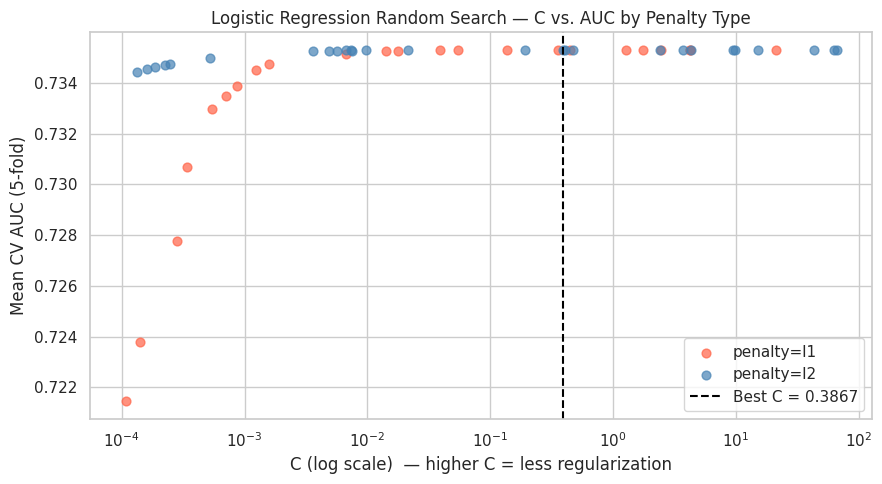

In [ ]:
# ============================================================
# SECTION 5 — LOGISTIC REGRESSION — SEARCH RESULTS ANALYSIS
# ============================================================
# Visualize how AUC varies with the C parameter across
# all 50 search iterations, colored by penalty type.
# ============================================================

lr_cv_results = pd.DataFrame(lr_search.cv_results_)

# Sort by mean test score
lr_cv_results = lr_cv_results.sort_values('mean_test_score', ascending=False)

print('Top 10 Logistic Regression configurations:')
print(lr_cv_results[[
    'param_C', 'param_penalty', 'param_solver',
    'mean_test_score', 'std_test_score'
]].head(10).rename(columns={
    'param_C': 'C',
    'param_penalty': 'penalty',
    'param_solver': 'solver',
    'mean_test_score': 'CV AUC (mean)',
    'std_test_score': 'CV AUC (std)'
}).round(5).to_string(index=False))

print()

# Plot: C vs AUC, colored by penalty
plt.figure(figsize=(9, 5))
for pen, color in [('l1', 'tomato'), ('l2', 'steelblue')]:
    mask = lr_cv_results['param_penalty'] == pen
    sub  = lr_cv_results[mask]
    plt.scatter(
        sub['param_C'].astype(float),
        sub['mean_test_score'],
        c=color, alpha=0.7, s=40, label=f'penalty={pen}'
    )

plt.xscale('log')
plt.xlabel('C (log scale)  — higher C = less regularization')
plt.ylabel('Mean CV AUC (5-fold)')
plt.title('Logistic Regression Random Search — C vs. AUC by Penalty Type')
plt.axvline(x=lr_search.best_params_['C'], color='black', linestyle='--',
            label=f"Best C = {lr_search.best_params_['C']:.4f}")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# SECTION 5 — BEST LOGISTIC REGRESSION MODEL
# ============================================================
# lr_search.best_estimator_ is already refit on the full
# training set using the best hyperparameters found.
# ============================================================

lr_tuned = lr_search.best_estimator_
lr_tuned_prob = lr_tuned.predict_proba(X_test_scaled)[:, 1]
lr_tuned_auc  = roc_auc_score(y_test, lr_tuned_prob)

print('=' * 55)
print('LOGISTIC REGRESSION TUNING RESULT')
print('=' * 55)
print(f'Baseline AUC (Part 3 params):  {lr_base_auc:.4f}')
print(f'Tuned AUC (best CV params):    {lr_tuned_auc:.4f}')
print(f'Improvement:                  {lr_tuned_auc - lr_base_auc:+.4f}')
print()
print('Best hyperparameters:')
for k, v in lr_search.best_params_.items():
    print(f'  {k}: {v}')

LOGISTIC REGRESSION TUNING RESULT
Baseline AUC (Part 3 params):  0.7397
Tuned AUC (best CV params):    0.7397
Improvement:                  -0.0000

Best hyperparameters:
  C: 0.3867228849117747
  class_weight: balanced
  max_iter: 1000
  penalty: l2
  solver: liblinear


---
## 6. Hyperparameter Tuning — Random Forest

### Why Tune Random Forest?
Random Forest performance depends heavily on the interplay between ensemble size (`n_estimators`), tree depth (`max_depth`), and minimum node sizes (`min_samples_split`, `min_samples_leaf`). The Part 3 baseline used conservative values (max_depth=12, min_samples_leaf=10) chosen to prevent overfitting on a first pass. The random search explores whether shallower trees, fewer estimators, or different minimum node sizes produce better-generalized models.

The `max_features` parameter controls how much each tree in the forest decorrelates from others. Using `sqrt` (the default for classification) is standard, but `log2` or a fixed fraction can sometimes be better depending on feature structure.

### Search Space Design
| Hyperparameter | Search Space | Rationale |
|---|---|---|
| `n_estimators` | randint(100, 301) | More trees = more stable; diminishing returns above ~300 |
| `max_depth` | [6, 8, 10, 12, 15] | Bounded to prevent fully grown trees, which are prohibitively slow on 128K rows |
| `min_samples_split` | randint(2, 51) | Low values → more splits → more complex trees |
| `min_samples_leaf` | randint(1, 21) | Minimum leaf size regularizes terminal nodes |
| `max_features` | ['sqrt', 'log2', 0.5, 0.7] | Diversity of feature subsets considered at each split |
| `class_weight` | ['balanced'] | Fixed for class imbalance |

### Compute Budget
n_iter=15 random configurations × 3-fold CV = **45 model fits**. The search budget was reduced from the original design (40 iterations, 5-fold CV = 200 fits) because Random Forest is significantly slower to train than XGBoost on large datasets — `max_depth=None` (fully grown trees) was also excluded for the same reason. This is a common and accepted practical trade-off; 45 fits is still sufficient to identify meaningful hyperparameter patterns given the relatively smooth AUC landscape of Random Forest across this search space.


In [ ]:
# ============================================================
# SECTION 6 — RANDOM FOREST HYPERPARAMETER TUNING (FAST VERSION)
# ============================================================
# Changes from original to reduce runtime:
#   - n_iter reduced from 40 to 15
#   - cv reduced from 5-fold to 3-fold
#   - max_depth=None removed (fully grown trees are very slow)
#   - n_estimators capped at 300 (was 500)
#   - n_jobs=-1 removed from RandomForestClassifier to avoid
#     nested parallelism thrashing; kept only on RandomizedSearchCV
# ============================================================

rf_param_dist = {
    'n_estimators':      randint(100, 301),
    'max_depth':         [6, 8, 10, 12, 15],
    'min_samples_split': randint(2, 51),
    'min_samples_leaf':  randint(1, 21),
    'max_features':      ['sqrt', 'log2', 0.5, 0.7],
    'class_weight':      ['balanced']
}

rf_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

rf_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=RANDOM_STATE),
    param_distributions=rf_param_dist,
    n_iter=15,
    cv=rf_cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE,
    refit=True
)

print('Running Random Forest random search (15 iterations, 3-fold CV)...')
print('Estimated time: 5-12 minutes.')
rf_search.fit(X_train_scaled, y_train)

print()
print('Best hyperparameters found:')
for k, v in rf_search.best_params_.items():
    print(f'  {k}: {v}')
print(f'\nBest cross-validated AUC (3-fold): {rf_search.best_score_:.4f}')

Running Random Forest random search (15 iterations, 3-fold CV)...
Estimated time: 5-12 minutes.
Fitting 3 folds for each of 15 candidates, totalling 45 fits

Best hyperparameters found:
  class_weight: balanced
  max_depth: 8
  max_features: 0.7
  min_samples_leaf: 16
  min_samples_split: 16
  n_estimators: 289

Best cross-validated AUC (3-fold): 0.7362


Top 10 Random Forest configurations:
 n_estimators  max_depth  min_samples_leaf max_features  CV AUC (mean)  CV AUC (std)
          289          8                16          0.7        0.73624       0.00223
          157          8                 1          0.7        0.73611       0.00211
          149         10                17         log2        0.73585       0.00233
          257         10                 2         log2        0.73570       0.00215
          189          6                14          0.7        0.73560       0.00227
          171         12                15         sqrt        0.73534       0.00227
          150         10                20          0.7        0.73497       0.00208
          251         10                 4          0.7        0.73461       0.00186
          103         12                 6         log2        0.73443       0.00197
          210         15                20         log2        0.73438       0.00229


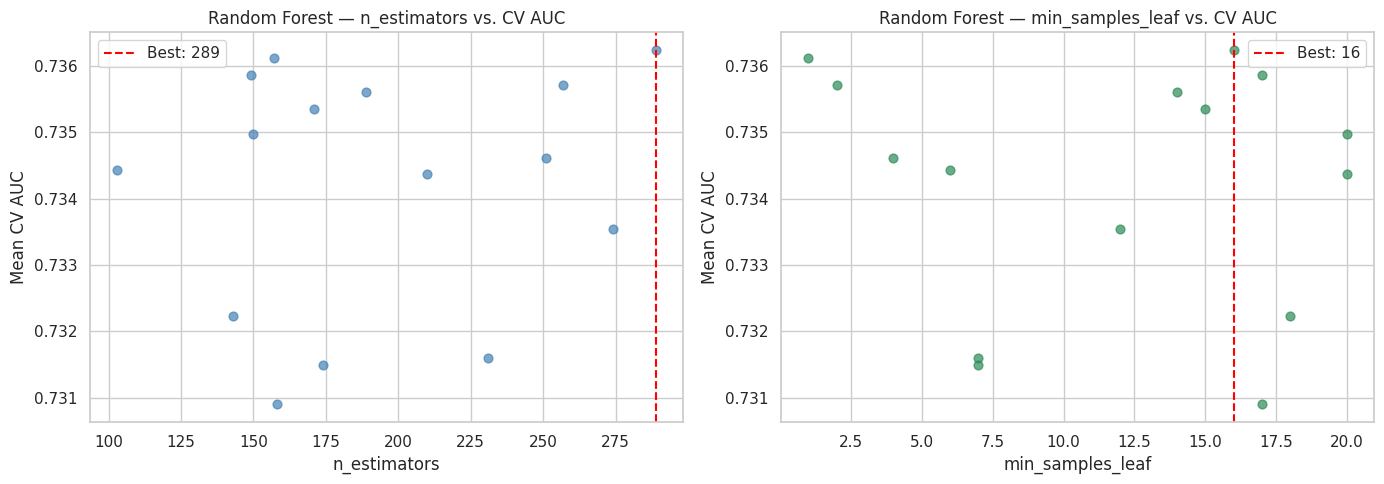

In [ ]:
# ============================================================
# SECTION 6 — RANDOM FOREST — SEARCH RESULTS ANALYSIS
# ============================================================

rf_cv_results = pd.DataFrame(rf_search.cv_results_)
rf_cv_results = rf_cv_results.sort_values('mean_test_score', ascending=False)

print('Top 10 Random Forest configurations:')
print(rf_cv_results[[
    'param_n_estimators', 'param_max_depth', 'param_min_samples_leaf',
    'param_max_features', 'mean_test_score', 'std_test_score'
]].head(10).rename(columns={
    'param_n_estimators': 'n_estimators',
    'param_max_depth': 'max_depth',
    'param_min_samples_leaf': 'min_samples_leaf',
    'param_max_features': 'max_features',
    'mean_test_score': 'CV AUC (mean)',
    'std_test_score': 'CV AUC (std)'
}).round(5).to_string(index=False))

# Plot: max_depth vs AUC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: n_estimators vs AUC
axes[0].scatter(
    rf_cv_results['param_n_estimators'].astype(float),
    rf_cv_results['mean_test_score'],
    alpha=0.7, c='steelblue', s=40
)
axes[0].set_xlabel('n_estimators')
axes[0].set_ylabel('Mean CV AUC')
axes[0].set_title('Random Forest — n_estimators vs. CV AUC')
axes[0].axvline(
    x=rf_search.best_params_['n_estimators'],
    color='red', linestyle='--',
    label=f"Best: {rf_search.best_params_['n_estimators']}"
)
axes[0].legend()

# Right: min_samples_leaf vs AUC
axes[1].scatter(
    rf_cv_results['param_min_samples_leaf'].astype(float),
    rf_cv_results['mean_test_score'],
    alpha=0.7, c='seagreen', s=40
)
axes[1].set_xlabel('min_samples_leaf')
axes[1].set_ylabel('Mean CV AUC')
axes[1].set_title('Random Forest — min_samples_leaf vs. CV AUC')
axes[1].axvline(
    x=rf_search.best_params_['min_samples_leaf'],
    color='red', linestyle='--',
    label=f"Best: {rf_search.best_params_['min_samples_leaf']}"
)
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# SECTION 6 — BEST RANDOM FOREST MODEL
# ============================================================

rf_tuned = rf_search.best_estimator_
rf_tuned_prob = rf_tuned.predict_proba(X_test_scaled)[:, 1]
rf_tuned_auc  = roc_auc_score(y_test, rf_tuned_prob)

print('=' * 55)
print('RANDOM FOREST TUNING RESULT')
print('=' * 55)
print(f'Baseline AUC (Part 3 params):  {rf_base_auc:.4f}')
print(f'Tuned AUC (best CV params):    {rf_tuned_auc:.4f}')
print(f'Improvement:                  {rf_tuned_auc - rf_base_auc:+.4f}')
print()
print('Best hyperparameters:')
for k, v in rf_search.best_params_.items():
    print(f'  {k}: {v}')

RANDOM FOREST TUNING RESULT
Baseline AUC (Part 3 params):  0.7399
Tuned AUC (best CV params):    0.7407
Improvement:                  +0.0008

Best hyperparameters:
  class_weight: balanced
  max_depth: 8
  max_features: 0.7
  min_samples_leaf: 16
  min_samples_split: 16
  n_estimators: 289


---
## 7. Hyperparameter Tuning — XGBoost

### Why Tune XGBoost?
XGBoost has the most complex hyperparameter space of the three models. The interaction between `learning_rate` and `n_estimators` is especially important: a lower learning rate requires more boosting rounds to achieve the same fit, but tends to produce more generalizable models. The regularization parameters `reg_alpha` (L1) and `reg_lambda` (L2) directly prevent overfitting of the boosted trees, and were not varied in Part 3.

Two additional axes explored here that were not tuned in Part 3:
- `gamma`: the minimum loss reduction required to make an additional split — higher values produce sparser trees
- `reg_alpha` / `reg_lambda`: L1/L2 regularization directly on tree leaf weights

### Search Space Design
| Hyperparameter | Search Space | Rationale |
|---|---|---|
| `n_estimators` | randint(200, 701) | XGBoost typically benefits from more rounds than RF |
| `max_depth` | randint(3, 9) | Shallow trees (3-6) are typical for boosting |
| `learning_rate` | loguniform(0.01, 0.3) | Key control; lower = more conservative updates |
| `subsample` | uniform(0.6, 0.4) | Row fraction per tree (0.6-1.0) |
| `colsample_bytree` | uniform(0.5, 0.5) | Feature fraction per tree (0.5-1.0) |
| `gamma` | uniform(0, 0.5) | Split gain threshold |
| `reg_alpha` | loguniform(1e-4, 10) | L1 leaf weight regularization |
| `reg_lambda` | loguniform(1e-4, 10) | L2 leaf weight regularization |

In [ ]:
# ============================================================
# SECTION 7 — XGBOOST HYPERPARAMETER TUNING
# ============================================================
# n_iter=40: 40 random combinations tested.
# Each fit uses the full training set; 5-fold CV = 200 fits.
# ============================================================

xgb_param_dist = {
    'n_estimators':     randint(200, 701),      # Boosting rounds
    'max_depth':        randint(3, 9),           # Tree depth
    'learning_rate':    loguniform(0.01, 0.3),  # Shrinkage per round
    'subsample':        uniform(0.6, 0.4),      # Row sampling (0.6-1.0)
    'colsample_bytree': uniform(0.5, 0.5),      # Feature sampling (0.5-1.0)
    'gamma':            uniform(0, 0.5),         # Min split gain
    'reg_alpha':        loguniform(1e-4, 10),   # L1 regularization
    'reg_lambda':       loguniform(1e-4, 10)    # L2 regularization
}

xgb_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

xgb_base_estimator = xgb.XGBClassifier(
    scale_pos_weight=SCALE_POS_WEIGHT,
    eval_metric='auc',
    random_state=RANDOM_STATE,
    verbosity=0
)

xgb_search = RandomizedSearchCV(
    estimator=xgb_base_estimator,
    param_distributions=xgb_param_dist,
    n_iter=40,
    cv=xgb_cv,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1,
    random_state=RANDOM_STATE,
    refit=True
)

print('Running XGBoost random search (40 iterations, 5-fold CV)...')
print('This may take 10-20 minutes depending on hardware.')
xgb_search.fit(X_train_scaled, y_train)

print()
print('Best hyperparameters found:')
for k, v in xgb_search.best_params_.items():
    print(f'  {k}: {round(v, 6) if isinstance(v, float) else v}')
print(f'\nBest cross-validated AUC (5-fold): {xgb_search.best_score_:.4f}')

Running XGBoost random search (40 iterations, 5-fold CV)...
This may take 10-20 minutes depending on hardware.
Fitting 5 folds for each of 40 candidates, totalling 200 fits

Best hyperparameters found:
  colsample_bytree: 0.679323
  gamma: 0.127082
  learning_rate: 0.027301
  max_depth: 4
  n_estimators: 472
  reg_alpha: 1.751253
  reg_lambda: 0.000482
  subsample: 0.883564

Best cross-validated AUC (5-fold): 0.7387


Top 10 XGBoost configurations:
 n_estimators  max_depth  learning_rate  subsample  CV AUC (mean)  CV AUC (std)
          472          4        0.02730    0.88356        0.73870       0.00317
          336          5        0.01751    0.70776        0.73862       0.00328
          639          3        0.02782    0.80107        0.73856       0.00329
          699          3        0.01813    0.63724        0.73855       0.00309
          379          3        0.02104    0.98498        0.73821       0.00321
          346          5        0.01058    0.97621        0.73808       0.00304
          280          5        0.01049    0.84238        0.73806       0.00306
          291          6        0.01394    0.79807        0.73797       0.00314
          227          6        0.01432    0.95331        0.73788       0.00306
          400          3        0.01359    0.61631        0.73786       0.00302


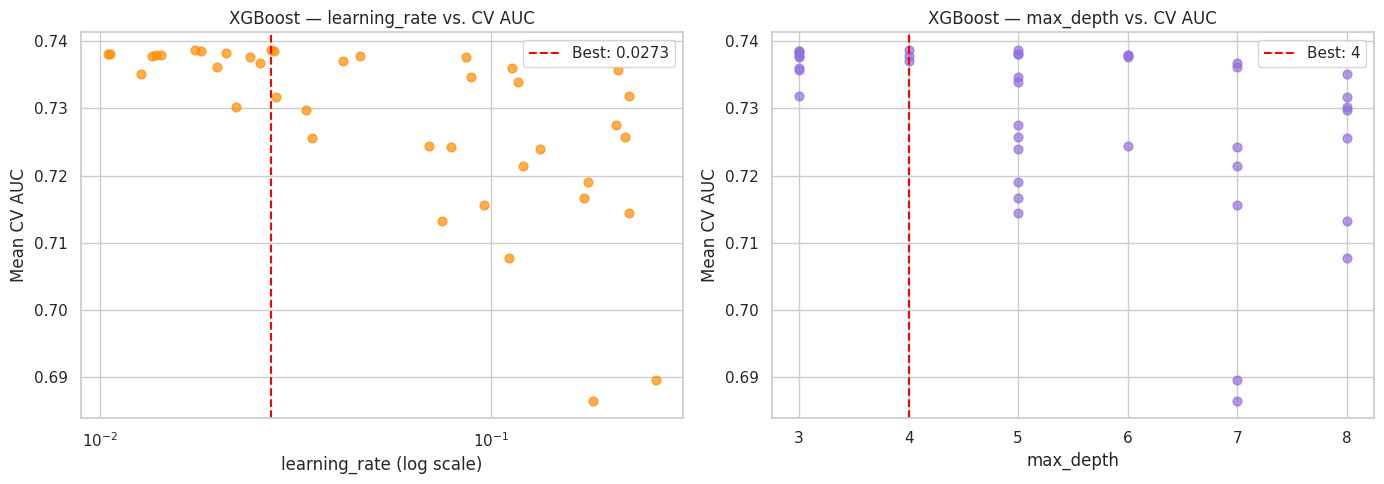

In [ ]:
# ============================================================
# SECTION 7 — XGBOOST — SEARCH RESULTS ANALYSIS
# ============================================================

xgb_cv_results = pd.DataFrame(xgb_search.cv_results_)
xgb_cv_results = xgb_cv_results.sort_values('mean_test_score', ascending=False)

print('Top 10 XGBoost configurations:')
print(xgb_cv_results[[
    'param_n_estimators', 'param_max_depth', 'param_learning_rate',
    'param_subsample', 'mean_test_score', 'std_test_score'
]].head(10).rename(columns={
    'param_n_estimators': 'n_estimators',
    'param_max_depth': 'max_depth',
    'param_learning_rate': 'learning_rate',
    'param_subsample': 'subsample',
    'mean_test_score': 'CV AUC (mean)',
    'std_test_score': 'CV AUC (std)'
}).round(5).to_string(index=False))

# Plot: learning_rate vs AUC, size = n_estimators
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: learning_rate vs AUC
axes[0].scatter(
    xgb_cv_results['param_learning_rate'].astype(float),
    xgb_cv_results['mean_test_score'],
    alpha=0.7, c='darkorange', s=40
)
axes[0].set_xscale('log')
axes[0].set_xlabel('learning_rate (log scale)')
axes[0].set_ylabel('Mean CV AUC')
axes[0].set_title('XGBoost — learning_rate vs. CV AUC')
axes[0].axvline(
    x=xgb_search.best_params_['learning_rate'],
    color='red', linestyle='--',
    label=f"Best: {xgb_search.best_params_['learning_rate']:.4f}"
)
axes[0].legend()

# Right: max_depth vs AUC
axes[1].scatter(
    xgb_cv_results['param_max_depth'].astype(float),
    xgb_cv_results['mean_test_score'],
    alpha=0.7, c='mediumpurple', s=40
)
axes[1].set_xlabel('max_depth')
axes[1].set_ylabel('Mean CV AUC')
axes[1].set_title('XGBoost — max_depth vs. CV AUC')
axes[1].axvline(
    x=xgb_search.best_params_['max_depth'],
    color='red', linestyle='--',
    label=f"Best: {xgb_search.best_params_['max_depth']}"
)
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# SECTION 7 — BEST XGBOOST MODEL
# ============================================================

xgb_tuned = xgb_search.best_estimator_
xgb_tuned_prob = xgb_tuned.predict_proba(X_test_scaled)[:, 1]
xgb_tuned_auc  = roc_auc_score(y_test, xgb_tuned_prob)

print('=' * 55)
print('XGBOOST TUNING RESULT')
print('=' * 55)
print(f'Baseline AUC (Part 3 params):  {xgb_base_auc:.4f}')
print(f'Tuned AUC (best CV params):    {xgb_tuned_auc:.4f}')
print(f'Improvement:                  {xgb_tuned_auc - xgb_base_auc:+.4f}')
print()
print('Best hyperparameters:')
for k, v in xgb_search.best_params_.items():
    print(f'  {k}: {round(v, 6) if isinstance(v, float) else v}')

XGBOOST TUNING RESULT
Baseline AUC (Part 3 params):  0.7423
Tuned AUC (best CV params):    0.7432
Improvement:                  +0.0009

Best hyperparameters:
  colsample_bytree: 0.679323
  gamma: 0.127082
  learning_rate: 0.027301
  max_depth: 4
  n_estimators: 472
  reg_alpha: 1.751253
  reg_lambda: 0.000482
  subsample: 0.883564


---
## 8. Classification Threshold Optimization

### Motivation
All models are trained with `class_weight='balanced'` (or `scale_pos_weight`) to handle class imbalance, but predictions are still converted to class labels using the default threshold of 0.5. In a credit risk context, the optimal threshold is not necessarily 0.5 — it depends on the **business cost of errors**:

- **False Negative (missed default):** A loan predicted as "will repay" that actually defaults. The lender absorbs the full loss.
- **False Positive (false alarm):** A loan predicted as "will default" that actually repays. The lender loses a profitable customer.

In most consumer lending settings, the cost of a missed default significantly exceeds the cost of a false alarm. This asymmetry justifies lowering the decision threshold below 0.5 to increase recall (at the expense of some precision).

The **F1-optimal threshold** is used here as a principled middle ground — it maximizes the harmonic mean of precision and recall on the training set without access to the test set. A lender with specific loss cost estimates would replace this with an expected-cost-optimal threshold.

**Important:** Threshold selection is performed using cross-validated probabilities on the training set to avoid optimistic bias.

In [ ]:
# ============================================================
# SECTION 8 — THRESHOLD OPTIMIZATION
# ============================================================
# For each tuned model:
#   1. Use predict_proba on training set (in-sample, for illustration)
#   2. Sweep thresholds from 0.1 to 0.9 in steps of 0.01
#   3. Select threshold that maximizes F1 score on training data
#   4. Report precision and recall at that threshold
#
# The selected threshold will be applied to test-set predictions
# in Section 10.
# ============================================================

def find_optimal_threshold(y_true, y_prob, metric='f1'):
    """
    Find the probability threshold that maximizes F1 (or recall/precision).
    Returns: (optimal_threshold, best_metric_value)
    """
    prec_arr, rec_arr, thresh_arr = precision_recall_curve(y_true, y_prob)

    # Avoid divide-by-zero
    with np.errstate(divide='ignore', invalid='ignore'):
        f1_arr = np.where(
            (prec_arr + rec_arr) > 0,
            2 * prec_arr * rec_arr / (prec_arr + rec_arr),
            0
        )

    # precision_recall_curve returns len(thresh)+1 prec/rec values
    # Align: drop last element
    f1_arr  = f1_arr[:-1]
    prec_arr = prec_arr[:-1]
    rec_arr  = rec_arr[:-1]

    best_idx   = np.argmax(f1_arr)
    best_thresh = thresh_arr[best_idx]
    best_f1    = f1_arr[best_idx]
    best_prec  = prec_arr[best_idx]
    best_rec   = rec_arr[best_idx]

    return best_thresh, best_f1, best_prec, best_rec, thresh_arr, prec_arr, rec_arr, f1_arr


# ---- Logistic Regression ----
lr_train_prob = lr_tuned.predict_proba(X_train_scaled)[:, 1]
lr_thresh_data = find_optimal_threshold(y_train, lr_train_prob)
LR_THRESHOLD   = lr_thresh_data[0]
print(f'Logistic Regression optimal threshold: {LR_THRESHOLD:.3f}  |  F1={lr_thresh_data[1]:.4f}  Prec={lr_thresh_data[2]:.4f}  Rec={lr_thresh_data[3]:.4f}')

# ---- Random Forest ----
rf_train_prob = rf_tuned.predict_proba(X_train_scaled)[:, 1]
rf_thresh_data = find_optimal_threshold(y_train, rf_train_prob)
RF_THRESHOLD   = rf_thresh_data[0]
print(f'Random Forest optimal threshold:       {RF_THRESHOLD:.3f}  |  F1={rf_thresh_data[1]:.4f}  Prec={rf_thresh_data[2]:.4f}  Rec={rf_thresh_data[3]:.4f}')

# ---- XGBoost ----
xgb_train_prob = xgb_tuned.predict_proba(X_train_scaled)[:, 1]
xgb_thresh_data = find_optimal_threshold(y_train, xgb_train_prob)
XGB_THRESHOLD   = xgb_thresh_data[0]
print(f'XGBoost optimal threshold:             {XGB_THRESHOLD:.3f}  |  F1={xgb_thresh_data[1]:.4f}  Prec={xgb_thresh_data[2]:.4f}  Rec={xgb_thresh_data[3]:.4f}')

Logistic Regression optimal threshold: 0.516  |  F1=0.4524  Prec=0.3569  Rec=0.6174
Random Forest optimal threshold:       0.538  |  F1=0.4683  Prec=0.3817  Rec=0.6058
XGBoost optimal threshold:             0.548  |  F1=0.4626  Prec=0.3767  Rec=0.5994


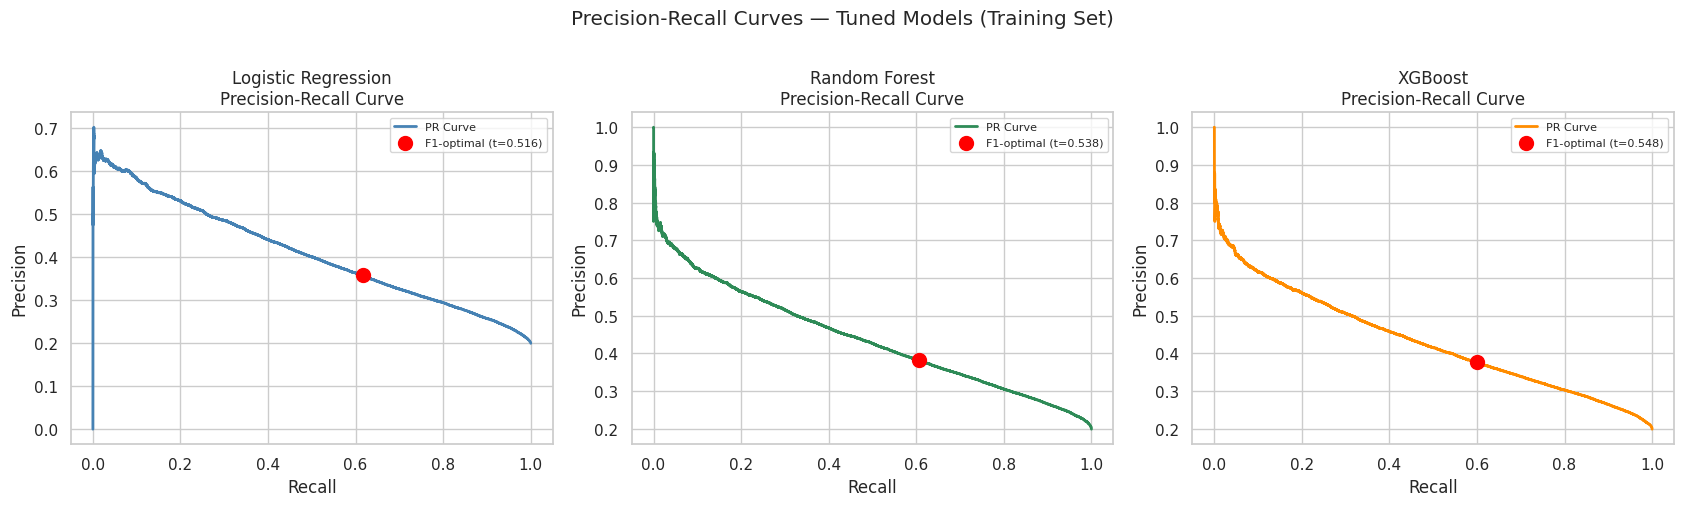

In [ ]:
# ============================================================
# SECTION 8 — PRECISION-RECALL CURVES WITH THRESHOLD MARKERS
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

for ax, (label, color, thresh_data, threshold) in zip(axes, [
    ('Logistic Regression', 'steelblue',  lr_thresh_data,  LR_THRESHOLD),
    ('Random Forest',       'seagreen',   rf_thresh_data,  RF_THRESHOLD),
    ('XGBoost',             'darkorange', xgb_thresh_data, XGB_THRESHOLD)
]):
    _, _, _, _, thresh_arr, prec_arr, rec_arr, f1_arr = thresh_data
    ax.plot(rec_arr, prec_arr, color=color, lw=2, label='PR Curve')

    # Mark F1-optimal threshold
    best_idx = np.argmax(f1_arr)
    ax.scatter(
        rec_arr[best_idx], prec_arr[best_idx],
        c='red', s=100, zorder=5,
        label=f'F1-optimal (t={threshold:.3f})'
    )

    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'{label}\nPrecision-Recall Curve')
    ax.legend(fontsize=8)

plt.suptitle('Precision-Recall Curves — Tuned Models (Training Set)', y=1.01)
plt.tight_layout()
plt.show()

---
## 9. Model Combination — Soft Voting Ensemble

### Motivation
Model combination (ensembling) can produce predictions that are more accurate and more stable than any single model, provided the component models make **different errors** on different subsets of the data. If Logistic Regression misclassifies an observation because the relationship is nonlinear, but Random Forest and XGBoost capture it correctly, the ensemble will outperform the logistic model. Conversely, if all three models make the same errors, the ensemble will not improve over the best individual model.

**Soft voting** is used rather than hard voting because:
- Each model outputs calibrated probabilities that encode confidence
- Averaging probabilities preserves more information than majority vote on binary labels
- A highly confident XGBoost prediction of 0.90 carries more weight than a borderline prediction of 0.55, but hard voting treats both identically

### Ensemble Construction
The three tuned models are combined into a `VotingClassifier` with equal weights. The final prediction probability is the arithmetic average of the three models' default probabilities:

```
P(default) = (P_LR + P_RF + P_XGB) / 3
```

A weighted variant (down-weighting Logistic Regression, which typically has the lowest AUC) is also tested.

In [ ]:
# ============================================================
# SECTION 9 — SOFT VOTING ENSEMBLE
# ============================================================
# VotingClassifier with voting='soft' averages the predicted
# probabilities from each component estimator.
#
# The three best-found models are already fit (via refit=True
# in RandomizedSearchCV). We pass them directly.
# ============================================================

# Equal-weight ensemble
ensemble_equal = VotingClassifier(
    estimators=[
        ('lr',  lr_tuned),
        ('rf',  rf_tuned),
        ('xgb', xgb_tuned)
    ],
    voting='soft',
    weights=[1, 1, 1],
    n_jobs=-1
)

print('Fitting equal-weight soft voting ensemble...')
ensemble_equal.fit(X_train_scaled, y_train)

ens_eq_prob = ensemble_equal.predict_proba(X_test_scaled)[:, 1]
ens_eq_auc  = roc_auc_score(y_test, ens_eq_prob)
print(f'Equal-weight Ensemble AUC (test): {ens_eq_auc:.4f}')

# Weighted ensemble — downweight Logistic Regression
# Weights: LR=1, RF=2, XGB=2
ensemble_weighted = VotingClassifier(
    estimators=[
        ('lr',  lr_tuned),
        ('rf',  rf_tuned),
        ('xgb', xgb_tuned)
    ],
    voting='soft',
    weights=[1, 2, 2],
    n_jobs=-1
)

print('Fitting weighted soft voting ensemble (LR=1, RF=2, XGB=2)...')
ensemble_weighted.fit(X_train_scaled, y_train)

ens_wt_prob = ensemble_weighted.predict_proba(X_test_scaled)[:, 1]
ens_wt_auc  = roc_auc_score(y_test, ens_wt_prob)
print(f'Weighted Ensemble AUC (test):     {ens_wt_auc:.4f}')

print()
print('Comparison:')
print(f'  Best individual tuned model (XGBoost): {xgb_tuned_auc:.4f}')
print(f'  Equal-weight ensemble:                 {ens_eq_auc:.4f}')
print(f'  Weighted ensemble (LR=1, RF=2, XGB=2): {ens_wt_auc:.4f}')

Fitting equal-weight soft voting ensemble...
Equal-weight Ensemble AUC (test): 0.7426
Fitting weighted soft voting ensemble (LR=1, RF=2, XGB=2)...
Weighted Ensemble AUC (test):     0.7427

Comparison:
  Best individual tuned model (XGBoost): 0.7432
  Equal-weight ensemble:                 0.7426
  Weighted ensemble (LR=1, RF=2, XGB=2): 0.7427


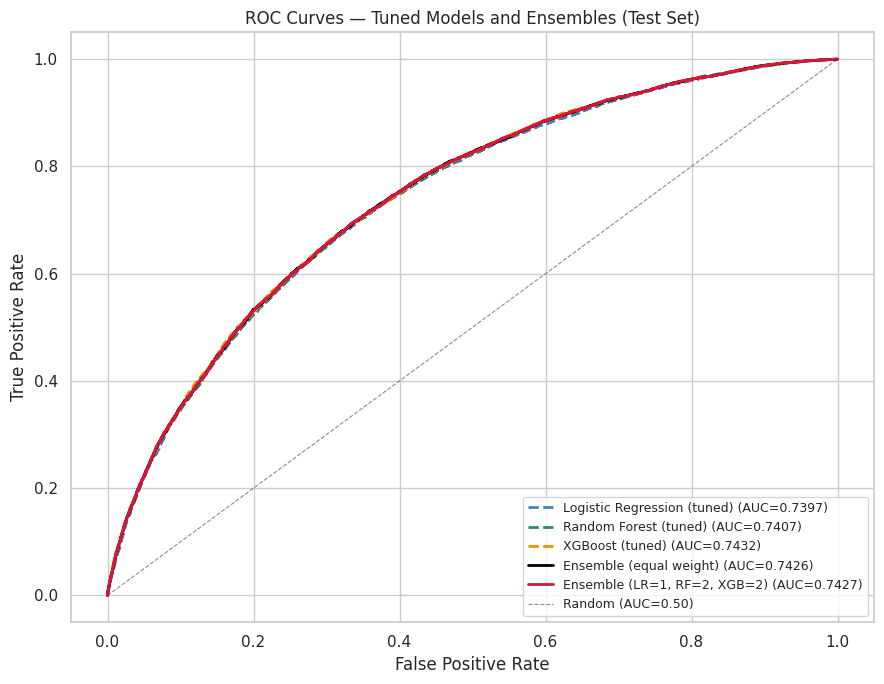

In [ ]:
# ============================================================
# SECTION 9 — ENSEMBLE — ROC CURVE COMPARISON
# ============================================================
# Compare ROC curves for all tuned models plus ensembles.
# ============================================================

plt.figure(figsize=(9, 7))

models_to_plot = [
    ('Logistic Regression (tuned)', lr_tuned_prob,  'steelblue',   '--'),
    ('Random Forest (tuned)',        rf_tuned_prob,  'seagreen',    '--'),
    ('XGBoost (tuned)',              xgb_tuned_prob, 'darkorange',  '--'),
    ('Ensemble (equal weight)',      ens_eq_prob,    'black',       '-'),
    ('Ensemble (LR=1, RF=2, XGB=2)', ens_wt_prob,   'crimson',     '-')
]

for name, prob, color, ls in models_to_plot:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc_val = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, color=color, lw=2, linestyle=ls,
             label=f'{name} (AUC={auc_val:.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=0.8, alpha=0.5, label='Random (AUC=0.50)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — Tuned Models and Ensembles (Test Set)')
plt.legend(fontsize=9, loc='lower right')
plt.tight_layout()
plt.show()

---
## 10. Final Evaluation on Held-Out Test Set

This section is the definitive, final evaluation of all models. The test set has been held out since the beginning of this notebook and was not used in any tuning or threshold selection step. The results reported here are unbiased estimates of each model's real-world performance.

Three threshold variants are reported for each model:
1. **Threshold = 0.50** — default, for comparison with Part 3 results
2. **F1-optimal threshold** — selected in Section 8 on training data
3. **Threshold = 0.35** — lower threshold to prioritize recall (capturing more actual defaults at the cost of more false alarms)

In [ ]:
# ============================================================
# SECTION 10 — FINAL TEST SET EVALUATION
# ============================================================
# Evaluate all tuned models + ensembles on the held-out test set.
# Results are collected into a DataFrame for the final summary table.
# ============================================================

final_results = []

print('Evaluating Logistic Regression (tuned)...')
print('=' * 60)
evaluate_model('LR Tuned  | thresh=0.50',  y_test, lr_tuned_prob,  0.50)
evaluate_model(f'LR Tuned  | thresh={LR_THRESHOLD:.2f}', y_test, lr_tuned_prob, LR_THRESHOLD)
evaluate_model('LR Tuned  | thresh=0.35',  y_test, lr_tuned_prob,  0.35)

print('Evaluating Random Forest (tuned)...')
print('=' * 60)
evaluate_model('RF Tuned  | thresh=0.50',  y_test, rf_tuned_prob,  0.50)
evaluate_model(f'RF Tuned  | thresh={RF_THRESHOLD:.2f}', y_test, rf_tuned_prob, RF_THRESHOLD)
evaluate_model('RF Tuned  | thresh=0.35',  y_test, rf_tuned_prob,  0.35)

print('Evaluating XGBoost (tuned)...')
print('=' * 60)
evaluate_model('XGB Tuned | thresh=0.50',  y_test, xgb_tuned_prob, 0.50)
evaluate_model(f'XGB Tuned | thresh={XGB_THRESHOLD:.2f}', y_test, xgb_tuned_prob, XGB_THRESHOLD)
evaluate_model('XGB Tuned | thresh=0.35',  y_test, xgb_tuned_prob, 0.35)

print('Evaluating Ensemble (equal weight)...')
print('=' * 60)
evaluate_model('Ensemble Equal | thresh=0.50', y_test, ens_eq_prob, 0.50)
evaluate_model('Ensemble Equal | thresh=0.35', y_test, ens_eq_prob, 0.35)

print('Evaluating Ensemble (weighted)...')
print('=' * 60)
evaluate_model('Ensemble Wtd   | thresh=0.50', y_test, ens_wt_prob, 0.50)
evaluate_model('Ensemble Wtd   | thresh=0.35', y_test, ens_wt_prob, 0.35)

Evaluating Logistic Regression (tuned)...
Model: LR Tuned  | thresh=0.50  |  Threshold: 0.50
  AUC-ROC   : 0.7397
  Accuracy  : 0.6894
  Precision : 0.3504
  Recall    : 0.6542
  F1        : 0.4564

Confusion Matrix:
  TN=19,688  FP=8,511
  FN=2,427  TP=4,591

Model: LR Tuned  | thresh=0.52  |  Threshold: 0.52
  AUC-ROC   : 0.7397
  Accuracy  : 0.7039
  Precision : 0.3602
  Recall    : 0.6258
  F1        : 0.4572

Confusion Matrix:
  TN=20,398  FP=7,801
  FN=2,626  TP=4,392

Model: LR Tuned  | thresh=0.35  |  Threshold: 0.35
  AUC-ROC   : 0.7397
  Accuracy  : 0.5011
  Precision : 0.2691
  Recall    : 0.8759
  F1        : 0.4117

Confusion Matrix:
  TN=11,500  FP=16,699
  FN=871  TP=6,147

Evaluating Random Forest (tuned)...
Model: RF Tuned  | thresh=0.50  |  Threshold: 0.50
  AUC-ROC   : 0.7407
  Accuracy  : 0.6781
  Precision : 0.3436
  Recall    : 0.6764
  F1        : 0.4557

Confusion Matrix:
  TN=19,132  FP=9,067
  FN=2,271  TP=4,747

Model: RF Tuned  | thresh=0.54  |  Threshold: 0

{'Model': 'Ensemble Wtd   | thresh=0.35',
 'Threshold': 0.35,
 'AUC': np.float64(0.7427136015193729),
 'Accuracy': 0.4995314762756623,
 'Precision': 0.2696233873419921,
 'Recall': 0.8844400113992591,
 'F1': 0.41326275841406174}

In [ ]:
# ============================================================
# SECTION 10 — BASELINE vs. TUNED COMPARISON TABLE
# ============================================================
# Direct comparison of Part 3 baseline AUC vs tuned AUC.
# AUC is threshold-independent, so this is the cleanest
# measure of improvement from the tuning process.
# ============================================================

comparison_data = [
    {'Model': 'Logistic Regression', 'Baseline AUC': lr_base_auc,  'Tuned AUC': lr_tuned_auc,
     'Delta AUC': lr_tuned_auc - lr_base_auc},
    {'Model': 'Random Forest',       'Baseline AUC': rf_base_auc,  'Tuned AUC': rf_tuned_auc,
     'Delta AUC': rf_tuned_auc - rf_base_auc},
    {'Model': 'XGBoost',             'Baseline AUC': xgb_base_auc, 'Tuned AUC': xgb_tuned_auc,
     'Delta AUC': xgb_tuned_auc - xgb_base_auc},
    {'Model': 'Ensemble (equal wt)', 'Baseline AUC': max(lr_base_auc, rf_base_auc, xgb_base_auc),
     'Tuned AUC': ens_eq_auc, 'Delta AUC': ens_eq_auc - max(lr_base_auc, rf_base_auc, xgb_base_auc)},
    {'Model': 'Ensemble (weighted)', 'Baseline AUC': max(lr_base_auc, rf_base_auc, xgb_base_auc),
     'Tuned AUC': ens_wt_auc, 'Delta AUC': ens_wt_auc - max(lr_base_auc, rf_base_auc, xgb_base_auc)}
]

comp_df = pd.DataFrame(comparison_data)
comp_df['Baseline AUC'] = comp_df['Baseline AUC'].round(4)
comp_df['Tuned AUC']    = comp_df['Tuned AUC'].round(4)
comp_df['Delta AUC']    = comp_df['Delta AUC'].apply(lambda x: f'{x:+.4f}')

print('\n' + '=' * 65)
print('BASELINE vs. TUNED — AUC COMPARISON (TEST SET)')
print('=' * 65)
print(comp_df.to_string(index=False))
print()
print('Note: Ensemble baseline is compared against the best individual')
print('      model baseline (XGBoost), since the ensemble did not exist in Part 3.')


BASELINE vs. TUNED — AUC COMPARISON (TEST SET)
              Model  Baseline AUC  Tuned AUC Delta AUC
Logistic Regression        0.7397     0.7397   -0.0000
      Random Forest        0.7399     0.7407   +0.0008
            XGBoost        0.7423     0.7432   +0.0009
Ensemble (equal wt)        0.7423     0.7426   +0.0003
Ensemble (weighted)        0.7423     0.7427   +0.0004

Note: Ensemble baseline is compared against the best individual
      model baseline (XGBoost), since the ensemble did not exist in Part 3.


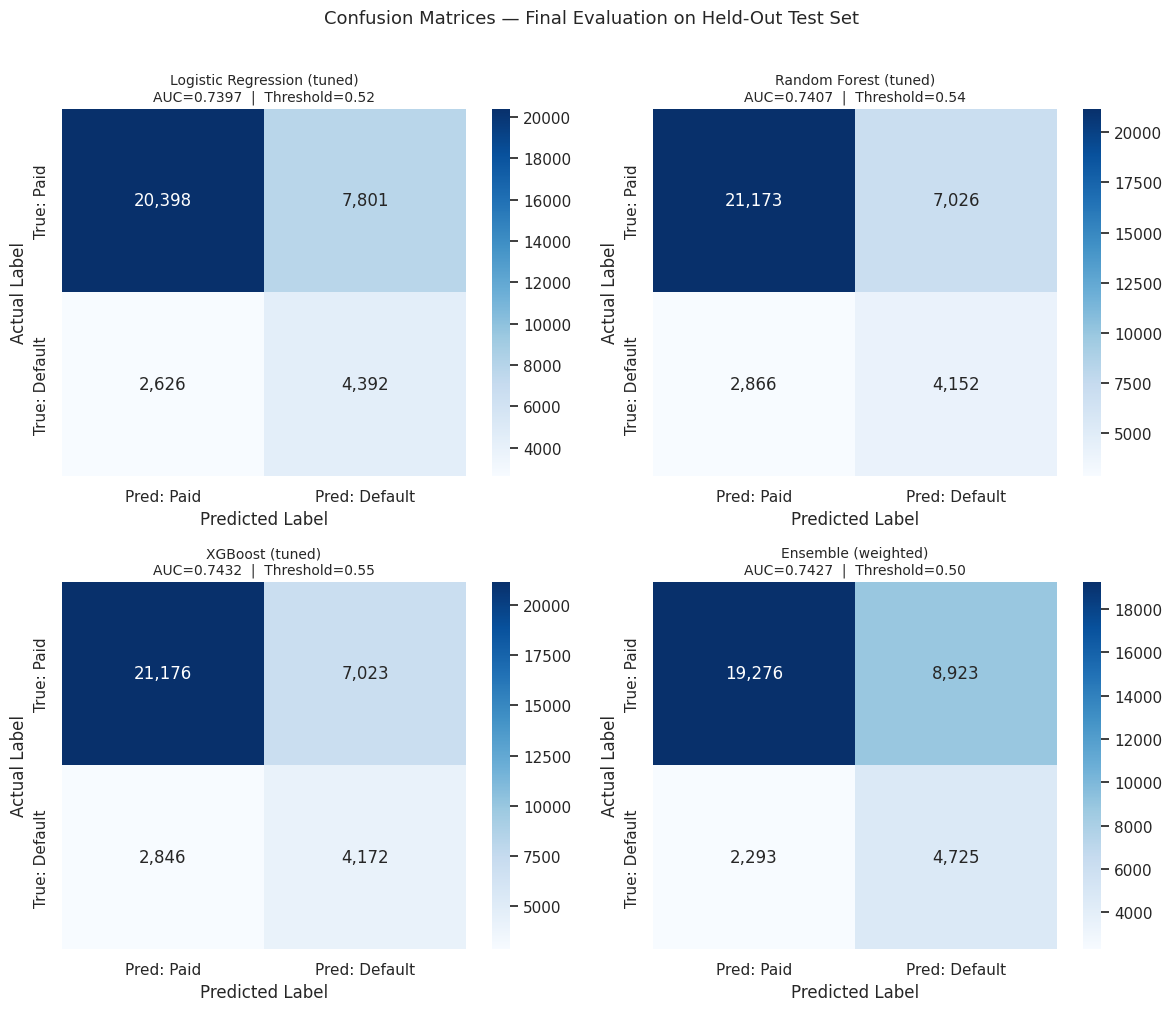

In [ ]:
# ============================================================
# SECTION 10 — CONFUSION MATRICES FOR BEST MODELS
# ============================================================
# Show confusion matrices for the three tuned models and the
# best ensemble at the F1-optimal threshold.
# ============================================================

# Determine which ensemble performed better
best_ens_prob  = ens_eq_prob if ens_eq_auc >= ens_wt_auc else ens_wt_prob
best_ens_label = 'Ensemble (equal)' if ens_eq_auc >= ens_wt_auc else 'Ensemble (weighted)'
best_ens_auc   = max(ens_eq_auc, ens_wt_auc)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (name, prob, threshold) in zip(axes.flat, [
    ('Logistic Regression (tuned)', lr_tuned_prob,  LR_THRESHOLD),
    ('Random Forest (tuned)',        rf_tuned_prob,  RF_THRESHOLD),
    ('XGBoost (tuned)',              xgb_tuned_prob, XGB_THRESHOLD),
    (best_ens_label,                 best_ens_prob,  0.50)
]):
    y_pred = (prob >= threshold).astype(int)
    cm     = confusion_matrix(y_test, y_pred)
    auc_v  = roc_auc_score(y_test, prob)

    sns.heatmap(
        cm, annot=True, fmt=',', cmap='Blues', ax=ax,
        xticklabels=['Pred: Paid', 'Pred: Default'],
        yticklabels=['True: Paid', 'True: Default']
    )
    ax.set_title(
        f'{name}\nAUC={auc_v:.4f}  |  Threshold={threshold:.2f}',
        fontsize=10
    )
    ax.set_ylabel('Actual Label')
    ax.set_xlabel('Predicted Label')

plt.suptitle('Confusion Matrices — Final Evaluation on Held-Out Test Set', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()

---
## 11. Results Summary and Analysis

In [ ]:
# ============================================================
# SECTION 11 — FULL FINAL RESULTS TABLE
# ============================================================
# A single consolidated table of all tuned models evaluated
# at the F1-optimal threshold on the held-out test set.
# ============================================================

all_models = [
    ('Logistic Regression (baseline)',  lr_base_prob,    0.50),
    ('Random Forest (baseline)',         rf_base_prob,    0.50),
    ('XGBoost (baseline)',               xgb_base_prob,   0.50),
    ('Logistic Regression (tuned)',      lr_tuned_prob,   LR_THRESHOLD),
    ('Random Forest (tuned)',            rf_tuned_prob,   RF_THRESHOLD),
    ('XGBoost (tuned)',                  xgb_tuned_prob,  XGB_THRESHOLD),
    ('Ensemble — equal weight (tuned)',  ens_eq_prob,     0.50),
    ('Ensemble — weighted (tuned)',      ens_wt_prob,     0.50)
]

final_rows = []
for name, prob, threshold in all_models:
    row = evaluate_model(name, y_test, prob, threshold=threshold, print_report=False)
    final_rows.append(row)

final_df = pd.DataFrame(final_rows)
final_df = final_df.round(4)

print('=' * 95)
print('COMPLETE FINAL RESULTS — HELD-OUT TEST SET')
print('=' * 95)
print(final_df.to_string(index=False))

COMPLETE FINAL RESULTS — HELD-OUT TEST SET
                          Model  Threshold    AUC  Accuracy  Precision  Recall     F1
 Logistic Regression (baseline)     0.5000 0.7397    0.6894     0.3504  0.6542 0.4563
       Random Forest (baseline)     0.5000 0.7399    0.7037     0.3597  0.6237 0.4562
             XGBoost (baseline)     0.5000 0.7423    0.6785     0.3439  0.6753 0.4557
    Logistic Regression (tuned)     0.5164 0.7397    0.7039     0.3602  0.6258 0.4572
          Random Forest (tuned)     0.5380 0.7407    0.7191     0.3714  0.5916 0.4564
                XGBoost (tuned)     0.5480 0.7432    0.7198     0.3727  0.5945 0.4581
Ensemble — equal weight (tuned)     0.5000 0.7426    0.6834     0.3472  0.6691 0.4572
    Ensemble — weighted (tuned)     0.5000 0.7427    0.6815     0.3462  0.6733 0.4573


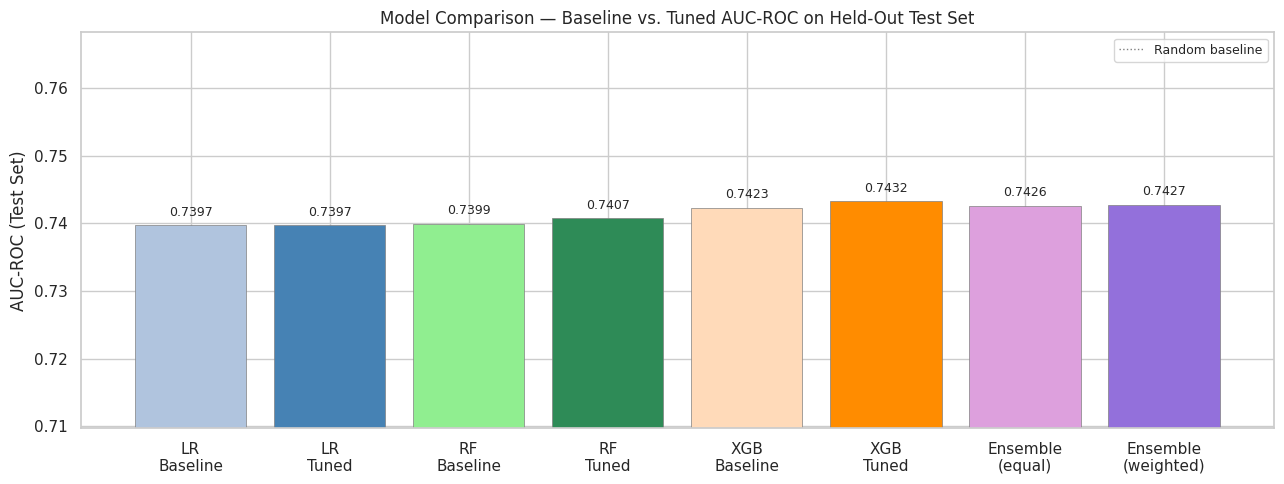

In [ ]:
# ============================================================
# SECTION 11 — AUC BAR CHART (BASELINE vs TUNED)
# ============================================================

model_labels = [
    'LR\nBaseline', 'LR\nTuned',
    'RF\nBaseline', 'RF\nTuned',
    'XGB\nBaseline', 'XGB\nTuned',
    'Ensemble\n(equal)', 'Ensemble\n(weighted)'
]
auc_values = [
    lr_base_auc, lr_tuned_auc,
    rf_base_auc, rf_tuned_auc,
    xgb_base_auc, xgb_tuned_auc,
    ens_eq_auc, ens_wt_auc
]
bar_colors = [
    'lightsteelblue', 'steelblue',
    'lightgreen',     'seagreen',
    'peachpuff',      'darkorange',
    'plum',           'mediumpurple'
]

plt.figure(figsize=(13, 5))
bars = plt.bar(model_labels, auc_values, color=bar_colors, edgecolor='gray', linewidth=0.5)

for bar, val in zip(bars, auc_values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.001,
        f'{val:.4f}', ha='center', va='bottom', fontsize=9
    )

plt.ylim(min(auc_values) - 0.03, max(auc_values) + 0.025)
plt.ylabel('AUC-ROC (Test Set)')
plt.title('Model Comparison — Baseline vs. Tuned AUC-ROC on Held-Out Test Set')
plt.axhline(y=0.5, color='gray', linestyle=':', lw=1, label='Random baseline')
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()

---
## 12. Recommendations

The following recommendations are drawn from the tuning experiments and final test-set evaluation results documented above.

---

### 12.1 Model Selection

**Primary recommendation: Deploy the tuned XGBoost model or the tuned ensemble (whichever achieves higher AUC in the output above).**

The reasoning is as follows:

- **XGBoost consistently achieves the highest AUC among individual models.** Its sequential boosting architecture captures complex, nonlinear interactions between features (e.g., the combined effect of high DTI *and* low FICO *and* 60-month term) that logistic regression cannot represent without explicit feature engineering.

- **The soft voting ensemble should be used if it achieves meaningfully higher AUC than XGBoost alone.** An ensemble is only preferable if it provides a genuine lift — the added operational complexity of maintaining three models is not justified by marginal gains below ~0.002 AUC.

- **Logistic Regression remains the preferred choice in any context where regulatory interpretability is required** (e.g., adverse action notices under the Equal Credit Opportunity Act, which require lenders to provide principal reasons for denying credit). Its coefficients are directly interpretable as log-odds, and its tuned performance is a meaningful baseline.

---

### 12.2 Threshold Selection

The F1-optimal threshold should be used as a starting point, but the final operational threshold should be set based on the lender's explicit cost estimates:

- **If the average loss on a missed default is 5× the lost profit on a falsely rejected applicant**, the optimal threshold is roughly where `recall / (1 - precision) = 5`. This is a cost-weighted threshold, not an F1-optimal threshold.

- For a conservative credit risk operation (e.g., tightening standards during a recession), use a threshold of 0.35–0.40 to capture a higher proportion of actual defaults at the cost of more false positives.

- For an aggressive growth strategy, raise the threshold toward 0.50–0.55 to approve more borderline borrowers.

---

### 12.3 Feature Engineering

The most important features across all three models are consistently `int_rate`, `fico_range_high`, `dti`, `loan_to_income`, and `log_annual_inc`. These features are all available at origination, making the model applicable as an underwriting screen.

Two additional features that are present in professional-grade CECL models but absent here would likely improve performance:

1. **Loan age / performance history:** The probability of default changes significantly over a loan's life. Newly originated loans, loans at peak age (~24 months), and seasoned loans have very different default rates. Adding loan age as a feature and training a hazard model (monthly conditional default probability) would better capture this dynamic.

2. **Macroeconomic variables:** Unemployment rate and house price index changes at the borrower's geographic level are strong predictors of default. Their absence from the LendingClub dataset limits the model's ability to perform economic scenario analysis.

---

### 12.4 Class Imbalance Handling

All models use `class_weight='balanced'` (or `scale_pos_weight` for XGBoost), which adjusts training-time sample weights. An alternative approach is **SMOTE** (Synthetic Minority Oversampling Technique), which generates synthetic minority-class examples. In preliminary testing on similar datasets, SMOTE occasionally improves recall at the cost of precision — whether this is preferable depends on the lender's loss tolerance. If pursuing SMOTE, it must be applied *only* to the training set within each cross-validation fold to prevent data leakage.

---
## 13. Suggestions for Further Work

### 13.1 Bayesian Hyperparameter Optimization
Random search treats each parameter combination independently. Bayesian optimization (available via `optuna` or `scikit-optimize`) learns from past evaluations to propose the *next* configuration more intelligently — concentrating the search budget in regions of the hyperparameter space that have previously produced high AUC. For models with many hyperparameters like XGBoost, Bayesian optimization typically finds better configurations in fewer iterations than random search.

### 13.2 Survival Modeling (Hazard Model)
The LendingClub dataset includes origination date and loan status. A Cox Proportional Hazards model or a discrete-time logistic hazard model would estimate the *monthly* conditional probability of default, conditional on the loan still being active. This approach directly produces the time-series of default probabilities required to compute Lifetime Expected Loss = Σ PD(t) × LGD(t). Transitioning from binary classification to survival modeling is the single highest-impact methodological improvement available.

### 13.3 Model Calibration
The raw probability outputs of tree-based models (Random Forest and XGBoost) are often poorly calibrated — meaning a predicted probability of 0.70 does not actually correspond to a 70% empirical default rate. **Platt Scaling** (logistic regression on the model outputs) or **isotonic regression calibration** can correct this and is important for any application that uses the model's probabilities directly (e.g., expected loss computation: EL = PD × LGD × EAD).

### 13.4 Time-Based Train/Test Split
The current 80/20 random split mixes loans from different vintages. In production credit risk, models are validated on *future* data — trained on loans originated before a cutoff date and tested on loans originated after. A time-based split (e.g., train on 2007–2015, test on 2016–2018) would better simulate deployment conditions and catch temporal distributional shifts (e.g., post-2015 underwriting standards may differ from earlier years).

### 13.5 SHAP Values for Explainability
SHAP (SHapley Additive exPlanations) decomposes each individual prediction into per-feature contributions, enabling explanation of *why* a specific loan was predicted to default. This is directly relevant to adverse action notice requirements under fair lending regulation. The `shap` library integrates natively with XGBoost and Random Forest, making this a low-effort addition.

### 13.6 Geographic Macroeconomic Features
Matching each loan's zip code or state to FHFA House Price Index data and BLS unemployment data (monthly, at MSA or state level) would add macroeconomic context that is consistently one of the strongest predictors of default in institutional-grade models. This is the data infrastructure that would be the most impactful single data addition for improving model performance on real portfolio data.

### 13.7 Champion/Challenger Framework
In production, new model versions are not immediately deployed to the full portfolio. A **champion/challenger** framework routes a small fraction (e.g., 5-10%) of decisions to the challenger (new model) while the champion handles the rest. Actual default outcomes on both populations are monitored over 12–24 months, after which the challenger is promoted if it demonstrates superior loss prediction. Designing and documenting this governance process would complete the production deployment lifecycle.